# Part 2: Statistical EDA, Hypothesis Testing & Visualization

## AI Supply Chain Risk Intelligence Platform

In this notebook, statistical analysis is performed on the cleaned supply chain dataset. The analysis includes:

- Initial inspection
- NumPy operations
- Descriptive statistics
- Feature engineering
- Pivot tables
- Grouped analysis
- Bucket segmentation
- Correlation analysis
- Hypothesis testing
- Data visualization

## Task 1: Initial Inspection

In [2]:
# importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from scipy import stats

In [3]:
# loading dataset
df = pd.read_csv("../data/supply_chain_analysis.csv")

In [10]:
# dataset shape
df.shape

(44965, 49)

In [11]:
# display first five records
df.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_amount,tax_amount,customer_id,order_date,order_status,...,risk_event_count,max_severity,total_estimated_loss,warehouse_name,warehouse_type,storage_capacity,order_month,order_year,profit,net_sales
0,1,ORD000001,205,3,1390.65,292.04,194.00,2368,11-04-2026,Delivered,...,0,No Risk,0,Bengaluru Warehouse,Regional Warehouse,142257,April,2026,886.95,4073.91
1,2,ORD000002,1144,5,870.75,87.08,213.33,3923,17-11-2024,Shipped,...,0,No Risk,0,Nagpur Warehouse,Distribution Center,115778,November,2024,1128.75,4480.00
2,3,ORD000002,840,5,2018.28,1311.88,438.98,3923,17-11-2024,Shipped,...,0,No Risk,0,Chandigarh Warehouse,Distribution Center,206333,November,2024,2446.40,9218.50
3,4,ORD000003,245,1,117.18,7.03,5.51,4090,06-12-2024,Delivered,...,0,No Risk,0,Visakhapatnam Warehouse,Regional Warehouse,155087,December,2024,24.18,115.66
4,5,ORD000004,4140,1,1345.36,228.71,55.83,2464,04-05-2026,Delivered,...,0,No Risk,0,Bengaluru Warehouse,Regional Warehouse,142257,May,2026,341.36,1172.48


In [12]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44965 entries, 0 to 44964
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_id         44965 non-null  int64  
 1   order_id              44965 non-null  str    
 2   product_id            44965 non-null  int64  
 3   quantity              44965 non-null  int64  
 4   unit_price            44965 non-null  float64
 5   discount_amount       44965 non-null  float64
 6   tax_amount            44965 non-null  float64
 7   customer_id           44965 non-null  int64  
 8   order_date            44965 non-null  str    
 9   order_status          44965 non-null  str    
 10  payment_method        44965 non-null  str    
 11  payment_status        44965 non-null  str    
 12  product_name          44965 non-null  str    
 13  supplier_id           44965 non-null  int64  
 14  brand                 44965 non-null  str    
 15  cost_price            44965 no

In [13]:
# statistical summary
df.describe(include='all')

,order_item_id,order_id,product_id,quantity,unit_price,discount_amount,tax_amount,customer_id,order_date,order_status,...,risk_event_count,max_severity,total_estimated_loss,warehouse_name,warehouse_type,storage_capacity,order_month,order_year,profit,net_sales
count,44965.000000,44965,44965.000000,44965.000000,44965.000000,44965.000000,44965.000000,44965.000000,44965,44965,...,44965.000000,44965,44965.000000,44965,44965,44965.000000,44965,44965.000000,44965.000000,44965.000000
unique,NaN,15000,NaN,NaN,NaN,NaN,NaN,NaN,731,6,...,NaN,5,NaN,25,3,NaN,12,NaN,NaN,NaN
top,NaN,ORD000005,NaN,NaN,NaN,NaN,NaN,NaN,07-06-2026,Delivered,...,NaN,No Risk,NaN,Mumbai Warehouse,Fulfillment Center,NaN,July,NaN,NaN,NaN
freq,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,113,26989,...,NaN,32268,NaN,2090,18065,NaN,3941,NaN,NaN,NaN
mean,22483.000000,NaN,2512.417013,2.997020,16071.287220,4785.109412,5228.186939,2512.639787,NaN,NaN,...,0.335172,NaN,11226.334527,NaN,NaN,179915.608362,NaN,2025.048994,10362.738153,48280.782276
std,12980.421764,NaN,1447.964333,1.414761,28295.752005,11581.482368,13737.299383,1452.135154,NaN,NaN,...,0.582215,NaN,45696.577186,NaN,NaN,57901.350400,NaN,0.709102,21739.543449,98656.472881
min,1.000000,NaN,1.000000,1.000000,23.000000,0.000000,1.060000,1.000000,NaN,NaN,...,0.000000,NaN,0.000000,NaN,NaN,63654.000000,NaN,2024.000000,3.000000,22.220000
25%,11242.000000,NaN,1250.000000,2.000000,1628.140000,248.150000,183.960000,1249.000000,NaN,NaN,...,0.000000,NaN,0.000000,NaN,NaN,134815.000000,NaN,2025.000000,822.400000,3807.640000
50%,22483.000000,NaN,2525.000000,3.000000,4461.540000,921.010000,567.410000,2489.000000,NaN,NaN,...,0.000000,NaN,0.000000,NaN,NaN,186414.000000,NaN,2025.000000,2484.690000,11350.350000
75%,33724.000000,NaN,3770.000000,4.000000,13580.160000,3439.740000,2269.600000,3799.000000,NaN,NaN,...,1.000000,NaN,2035.000000,NaN,NaN,222309.000000,NaN,2026.000000,8220.890000,37832.580000


In [14]:
# missing values
df.isnull().sum()

order_item_id               0
order_id                    0
product_id                  0
quantity                    0
unit_price                  0
discount_amount             0
tax_amount                  0
customer_id                 0
order_date                  0
order_status                0
payment_method              0
payment_status              0
product_name                0
supplier_id                 0
brand                       0
cost_price                  0
selling_price               0
profit_margin               0
product_rating              0
category_name               0
supplier_name               0
supplier_type               0
supplier_rating             0
lead_time_days              0
supplier_category           0
warehouse_id                0
available_stock             0
reserved_stock              0
damaged_stock               0
remaining_stock             0
inventory_status            0
shipment_id                 0
shipping_partner            0
shipped_da

In [15]:
# duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Task 2: Numpy Fundamentals

In [16]:
# Convert numerical columns into NumPy arrays

s = np.array(df["shipping_cost"])
q = np.array(df["quantity"])

print(s)
print(type(s))

print(q)
print(type(q))

[311.28 450.83 450.83 ... 538.01 538.01 538.01]
<class 'numpy.ndarray'>
[3 5 5 ... 3 4 5]
<class 'numpy.ndarray'>


In [17]:
# Vectorized arithmetic operation

shipping_cost_per_unit = s / q
scpu = np.array(shipping_cost_per_unit)

#diplaying 10 elements
print(scpu[:10])

[103.76        90.166       90.166       75.21       259.42
 129.71       373.24        93.31       124.41333333 186.62      ]


In [18]:
## Perform Boolean filtering with &

f = scpu[(scpu >= 50) &(scpu <= 100)]

print("Number of total shipping under range:", len(f))

print("Shipping cost per unit under 50 and 100 price range:")
print(f[:10])

Number of total shipping under range: 6973
Shipping cost per unit under 50 and 100 price range:
[90.166 90.166 75.21  93.31  58.04  58.04  58.915 97.182 59.92  55.175]


## Task 3: Descriptive Statistics

In [19]:
# Select two transaction-level numeric columns

sales = np.array(df["net_sales"])
profit = np.array(df["profit"])

In [20]:
# Calculation of descriptive statistics of net sales column
print("Net Sales") 
print("Mean :",np.mean(sales))
print("Median :",np.median(sales))
print("Standard deviation :",np.std(sales))
print("Variance :",np.var(sales))
print("Percentile :",np.percentile(sales, 90))

Net Sales
Mean : 48280.782275547645
Median : 11350.35
Standard deviation : 98655.37583893926
Variance : 9732883181.92236
Percentile : 138664.92799999996


In [21]:
# Calculation of descriptive statistics of profit column

print("Profit") 
print("Mean :",np.mean(profit))
print("Median :",np.median(profit))
print("Standard deviation :",np.std(profit))
print("Variance :",np.var(profit))
print("Percentile :",np.percentile(profit, 90))

Profit
Mean : 10362.73815323029
Median : 2484.69
Standard deviation : 21739.30170901278
Variance : 472597238.7954859
Percentile : 28628.68


## Task 4: Feature Engineering

In [22]:
# Calculate gross amount from quantity and unit price

df["gross_amount"] = df["quantity"] * df["unit_price"]

# Display the new feature

df[["quantity", "unit_price", "gross_amount"]].head()

,quantity,unit_price,gross_amount
0,3,1390.65,4171.95
1,5,870.75,4353.75
2,5,2018.28,10091.40
3,1,117.18,117.18
4,1,1345.36,1345.36


In [23]:
# Calculate risk exposure percentage from total estimated loss and gross amount

df["risk_exposure_percentage"] = ( df["total_estimated_loss"] / df["gross_amount"]) * 100

# Display the new feature
df[["gross_amount", "total_estimated_loss", "risk_exposure_percentage"]].head(10)

,gross_amount,total_estimated_loss,risk_exposure_percentage
0,4171.95,0,0.000000
1,4353.75,0,0.000000
2,10091.40,0,0.000000
3,117.18,0,0.000000
4,1345.36,0,0.000000
5,10162.62,0,0.000000
6,2307.02,2518,109.145131
7,9982.20,2518,25.224900
8,14549.04,2518,17.306984
9,3248.28,2518,77.517948


## Task 5: Grouped Analysis

In [24]:
# Pivot Table 1: Supply-chain risk by product category
# product categories that have the greatest supply-chain risk impact

category_risk = df.pivot_table(
    index="category_name",
    values=["risk_event_count", "total_estimated_loss"],
    aggfunc="sum"
)

category_risk

,risk_event_count,total_estimated_loss
category_name,,
Appliances,779,27298588
Automotive,742,23334032
Baby Products,729,22910559
Bags & Luggage,849,26864309
Beauty & Personal Care,709,25101869
Books,758,26142359
Electronics,788,26238370
Fashion,748,28913769
Footwear,816,29574707


In [25]:
# Pivot Table 2: Risk exposure by warehouse
# warehouses that have the highest average financial risk exposure

warehouse_risk = df.pivot_table(
    index="warehouse_name",
    values="risk_exposure_percentage",
    aggfunc="max"
)

warehouse_risk.sort_values(
    by="risk_exposure_percentage",
    ascending=False
)

,risk_exposure_percentage
warehouse_name,
Bhopal Warehouse,223910.151267
Raipur Warehouse,203882.343180
Pune Warehouse,183665.877712
Gurugram Warehouse,173909.989594
Delhi Warehouse,146842.762895
Lucknow Warehouse,127522.204807
Noida Warehouse,127440.503045
Vijayawada Warehouse,101772.717766
Kochi Warehouse,89943.033631


In [26]:
# Pivot Table 3: Supplier rating and operational performance
# suppliers with different ratings show differences in lead time and delivery performance

supplier_performance = df.pivot_table(
    index="supplier_rating",
    values=["lead_time_days", "delivery_days", "shipping_cost"],
    aggfunc="mean"
)

supplier_performance

,delivery_days,lead_time_days,shipping_cost
supplier_rating,,,
3.2,5.115346,10.491563,524.985246
3.3,5.115968,16.026211,527.191586
3.4,5.133909,12.817527,515.116631
3.5,5.112292,13.984802,533.594137
3.6,5.097801,12.687778,529.067522
3.7,5.199066,14.666522,519.171276
3.8,5.118519,16.106360,528.334175
3.9,5.077328,14.014971,522.201179
4.0,5.095823,13.665847,530.372567


In [27]:
# Multi-aggregation analysis by supplier type

supplier_risk = df.groupby("supplier_type").agg(
    {"risk_event_count": ["sum", "mean"],
    "total_estimated_loss": ["sum", "mean"]
})

supplier_risk

risk_event_count           total_estimated_loss              
                           sum      mean                  sum          mean
supplier_type                                                              
Distributor               1613  0.328179             56999059  11596.960122
Manufacturer             13458  0.336030            447793073  11180.850762

In [28]:
# Multi-aggregation GroupBy: Shipping partner performance
# compare delivery performance and shipping cost across shipping partners

shipping_performance = df.groupby("shipping_partner").agg(
    { "delivery_days": ["min", "max"],
    "shipping_cost": ["mean", "sum"]})

shipping_performance

delivery_days       shipping_cost            
                           min   max          mean         sum
shipping_partner                                              
Blue Dart                  1.0  14.0    527.954534  4760038.08
DTDC                       1.0  14.0    531.075064  3481728.12
Delhivery                  1.0  14.0    521.734697  7148287.08
Ecom Express               1.0  14.0    528.865392  2327536.59
Ekart Logistics            1.0  14.0    541.183417  2042967.40
India Post                 1.0  12.0    534.783577   475422.60
Shadowfax                  1.0  12.0    520.851526   692732.53
XpressBees                 1.0  14.0    518.984036  2749058.44

## Task 6: Bucket Segmentation

In [29]:
# Function to classify risk exposure into three buckets

def risk_exposure_bucket(value):
    if value <= 25:
        return "Low Risk Exposure"
    elif value <= 50:
        return "Medium Risk Exposure"
    else:
        return "High Risk Exposure"

In [30]:
# Apply the function to create a categorical risk column

df["risk_exposure_bucket"] = df["risk_exposure_percentage"].apply(risk_exposure_bucket)

# Display the result
df[["risk_exposure_percentage","risk_exposure_bucket"]].head(10)

,risk_exposure_percentage,risk_exposure_bucket
0,0.000000,Low Risk Exposure
1,0.000000,Low Risk Exposure
2,0.000000,Low Risk Exposure
3,0.000000,Low Risk Exposure
4,0.000000,Low Risk Exposure
5,0.000000,Low Risk Exposure
6,109.145131,High Risk Exposure
7,25.224900,Medium Risk Exposure
8,17.306984,Low Risk Exposure
9,77.517948,High Risk Exposure


In [31]:
df["risk_exposure_bucket"].value_counts()

risk_exposure_bucket
Low Risk Exposure       35809
High Risk Exposure       7821
Medium Risk Exposure     1335
Name: count, dtype: int64

In [32]:
df.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_amount,tax_amount,customer_id,order_date,order_status,...,warehouse_name,warehouse_type,storage_capacity,order_month,order_year,profit,net_sales,gross_amount,risk_exposure_percentage,risk_exposure_bucket
0,1,ORD000001,205,3,1390.65,292.04,194.00,2368,11-04-2026,Delivered,...,Bengaluru Warehouse,Regional Warehouse,142257,April,2026,886.95,4073.91,4171.95,0.0,Low Risk Exposure
1,2,ORD000002,1144,5,870.75,87.08,213.33,3923,17-11-2024,Shipped,...,Nagpur Warehouse,Distribution Center,115778,November,2024,1128.75,4480.00,4353.75,0.0,Low Risk Exposure
2,3,ORD000002,840,5,2018.28,1311.88,438.98,3923,17-11-2024,Shipped,...,Chandigarh Warehouse,Distribution Center,206333,November,2024,2446.40,9218.50,10091.40,0.0,Low Risk Exposure
3,4,ORD000003,245,1,117.18,7.03,5.51,4090,06-12-2024,Delivered,...,Visakhapatnam Warehouse,Regional Warehouse,155087,December,2024,24.18,115.66,117.18,0.0,Low Risk Exposure
4,5,ORD000004,4140,1,1345.36,228.71,55.83,2464,04-05-2026,Delivered,...,Bengaluru Warehouse,Regional Warehouse,142257,May,2026,341.36,1172.48,1345.36,0.0,Low Risk Exposure


## Task 7: Correlation Analysis

In [33]:
# Calculate Pearson correlation matrix for all numeric columns

correlation_matrix = df.corr(method='pearson', numeric_only=True)

print(correlation_matrix)

                          order_item_id  product_id  quantity  unit_price  \
order_item_id                  1.000000   -0.002392 -0.000253   -0.002339   
product_id                    -0.002392    1.000000  0.005401   -0.000812   
quantity                      -0.000253    0.005401  1.000000   -0.008200   
unit_price                    -0.002339   -0.000812 -0.008200    1.000000   
discount_amount               -0.002926   -0.003866  0.192786    0.726541   
tax_amount                    -0.003017   -0.004459  0.173728    0.817053   
customer_id                    0.021488   -0.000075  0.000491   -0.007533   
supplier_id                    0.000085   -0.009126 -0.000764    0.016818   
cost_price                    -0.001996   -0.002530 -0.008472    0.997767   
selling_price                 -0.002339   -0.000812 -0.008200    1.000000   
profit_margin                  0.002646    0.004859  0.008825    0.045747   
product_rating                 0.002068   -0.001479 -0.003156   -0.008560   

In [34]:
# Remove the diagonal
corr = correlation_matrix.mask(np.eye(correlation_matrix.shape[0], dtype=bool))

In [35]:
# Find highest absolute correlation

highest_pair = corr.stack().abs().idxmax()
highest_value = corr.stack().loc[highest_pair]

print("Highest Absolute Correlation:")
print(highest_pair, "=", highest_value)

Highest Absolute Correlation:
('unit_price', 'selling_price') = 1.0


In [36]:
# Find lowest absolute correlation

lowest_pair = corr.stack().abs().idxmin()
lowest_value = corr.stack().loc[lowest_pair]

print("\nLowest Absolute Correlation:")
print(lowest_pair, "=", lowest_value)


Lowest Absolute Correlation:
('quantity', 'reserved_stock') = 4.4403002039725265e-06


In [37]:
# Check for NaN correlation values

print("\nNumber of NaN correlation values:")
print(correlation_matrix.isna().sum().sum())


Number of NaN correlation values:
0


## Task 8: Frame a hypothesis test

### Hypothesis Testing

**Business Claim:**
The average total estimated loss differs between orders with risk events and orders without risk events.

**Null Hypothesis (H₀):**
There is no difference in the average total estimated loss between orders with risk events and orders without risk events.

**Alternate Hypothesis (H₁):**
There is a difference in the average total estimated loss between orders with risk events and orders without risk events.

**Test Type:**
Two-sample t-test, because the analysis compares the average total estimated loss of two independent groups.

**Significance Level:**
α = 0.05


## Task 9: Run the hypothesis test

In [38]:
# Create the two groups

# Orders with risk events
risk_orders = df[df["risk_event_count"] > 0]["total_estimated_loss"]

# Orders without risk events
no_risk_orders = df[df["risk_event_count"] == 0]["total_estimated_loss"]

In [39]:
# Check the group sizes and means

print("Risk orders:", len(risk_orders))
print("No-risk orders:", len(no_risk_orders))

print("Mean loss - Risk orders:", risk_orders.mean())
print("Mean loss - No-risk orders:", no_risk_orders.mean())

Risk orders: 12697
No-risk orders: 32268
Mean loss - Risk orders: 39756.80333937151
Mean loss - No-risk orders: 0.0


In [40]:
# Run the two-sample t-test

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(risk_orders, no_risk_orders, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 56.61570579025312
P-value: 0.0


In [41]:
# Make the decision at α = 0.05

significance_level = 0.05

if p_value < significance_level:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


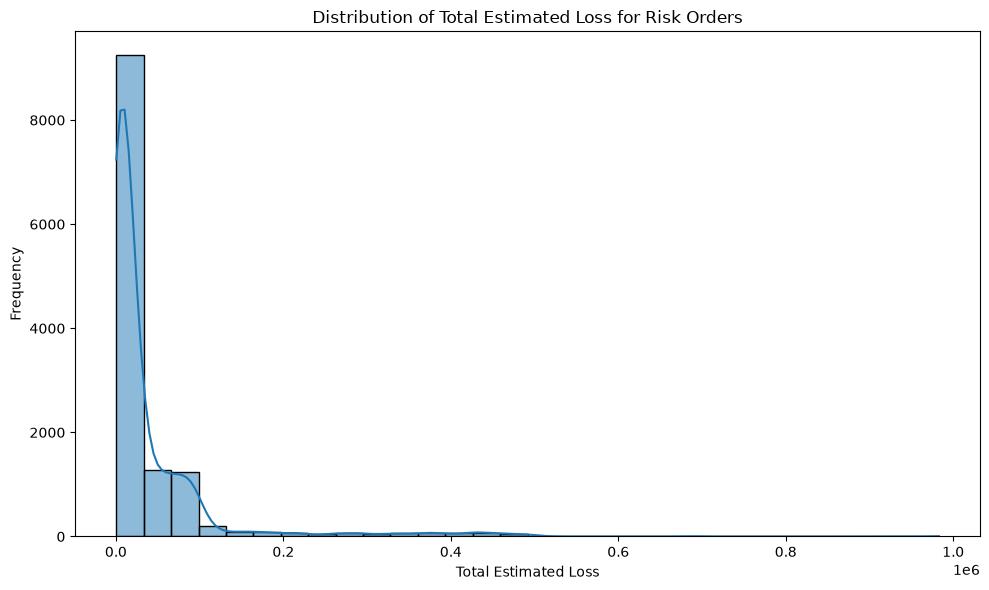

In [49]:
# Visual check of total estimated loss distribution

risk_orders = df[df["risk_event_count"] > 0]

plt.figure(figsize=(10, 6))

sns.histplot(
    risk_orders["total_estimated_loss"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Estimated Loss for Risk Orders")
plt.xlabel("Total Estimated Loss")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Assumption Check

The approximate normality assumption was checked visually using a histogram of "total_estimated_loss" for risk orders. The distribution is strongly right-skewed, with most observations concentrated at lower loss values and a long right tail. No formal normality test was performed because a visual histogram/skewness check was sufficient for this requirement.

The no-risk group has "total_estimated_loss = 0" for all observations, resulting in zero variance; therefore, its distribution cannot be meaningfully assessed for normality.

## Task 10 : Visualization

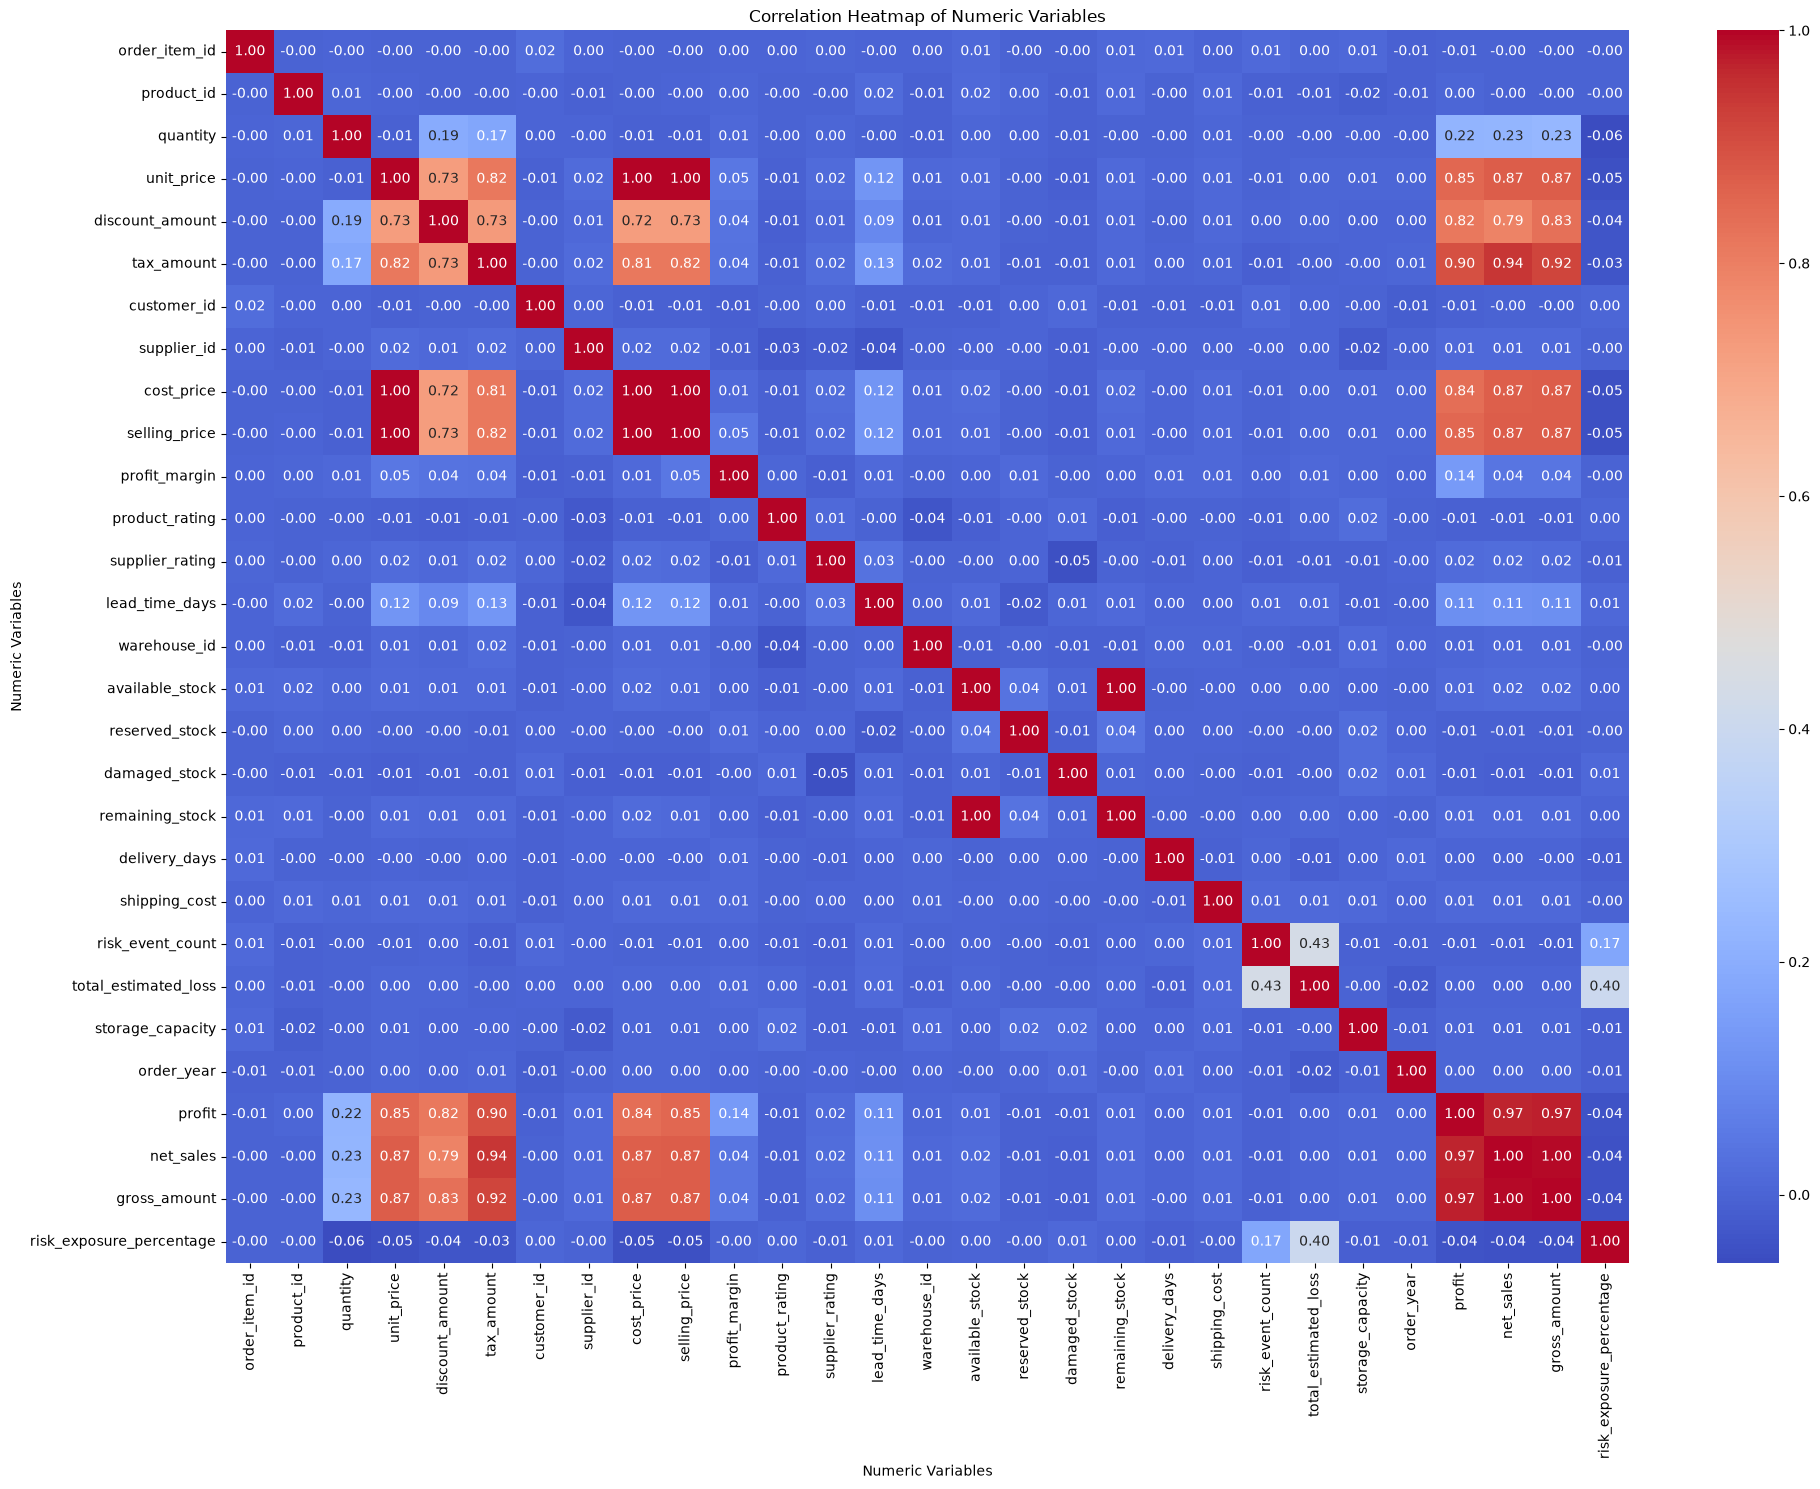

In [43]:
# 1. Correlation Heatmap

plt.figure(figsize=(20, 15))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap of Numeric Variables")
plt.xlabel("Numeric Variables")
plt.ylabel("Numeric Variables")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=500)
plt.show()

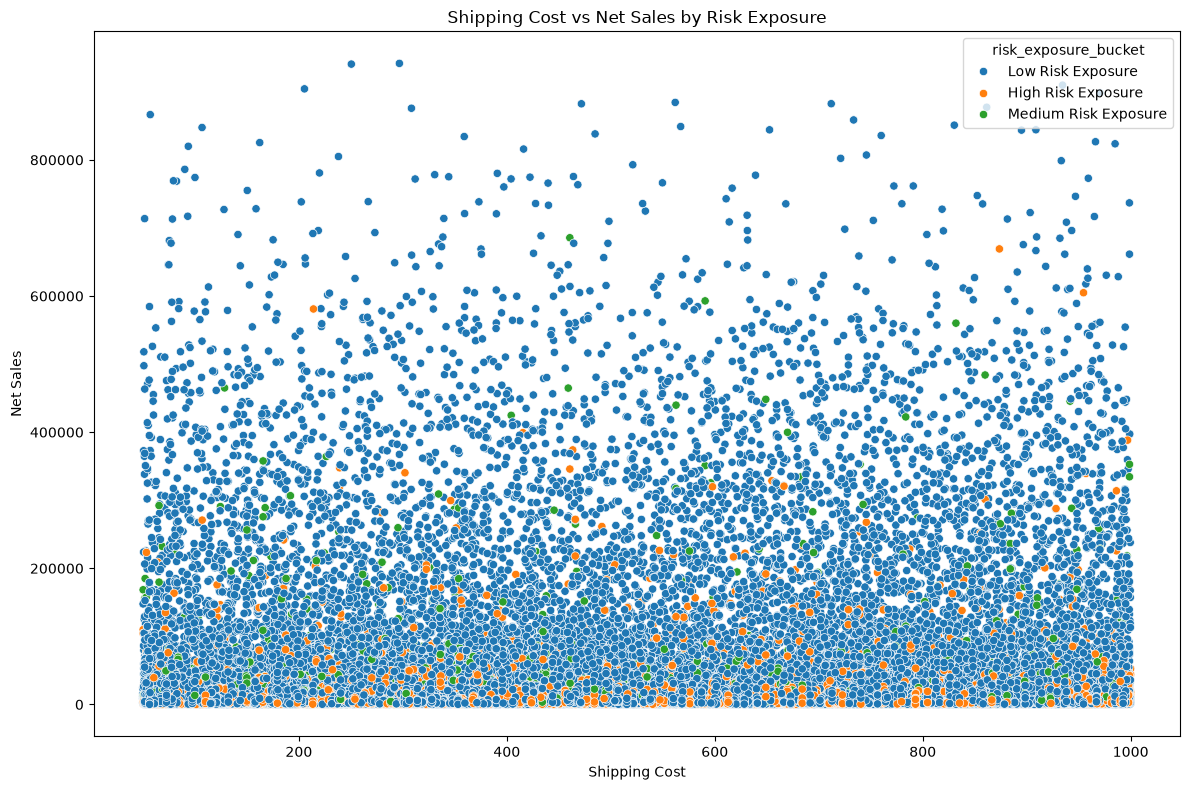

In [44]:
# 2. Scatter Plot: Shipping Cost vs Net Sales by Risk Exposure

plt.figure(figsize=(12,8))

sns.scatterplot(x="shipping_cost", y="net_sales", data=df, hue="risk_exposure_bucket")

plt.title("Shipping Cost vs Net Sales by Risk Exposure")
plt.xlabel("Shipping Cost")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("shipping_cost_vs_net_sales_risk.png", dpi=500)
plt.show()

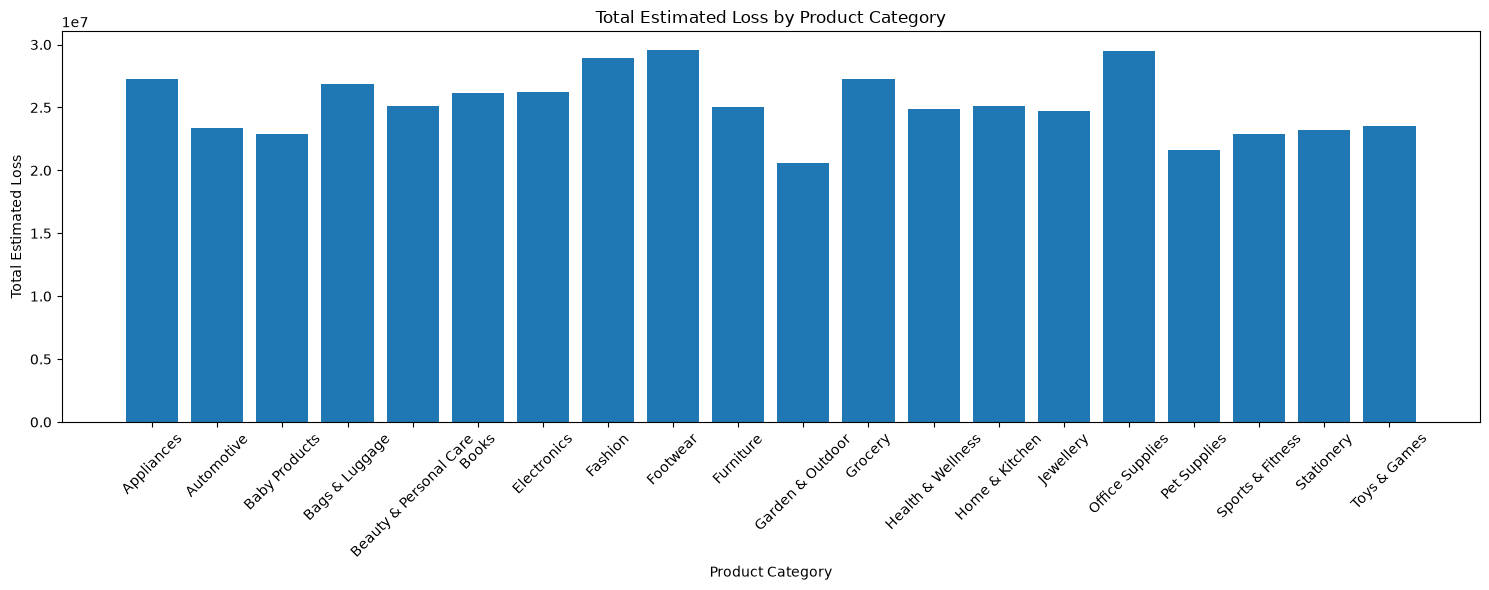

In [45]:
# 3. Total Estimated Loss by Product Category

category_loss = df.groupby("category_name")["total_estimated_loss"].sum()

plt.figure(figsize=(15,6))

plt.bar( category_loss.index, category_loss.values)

plt.title("Total Estimated Loss by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Estimated Loss")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("category_estimated_loss.png", dpi=500)
plt.show()

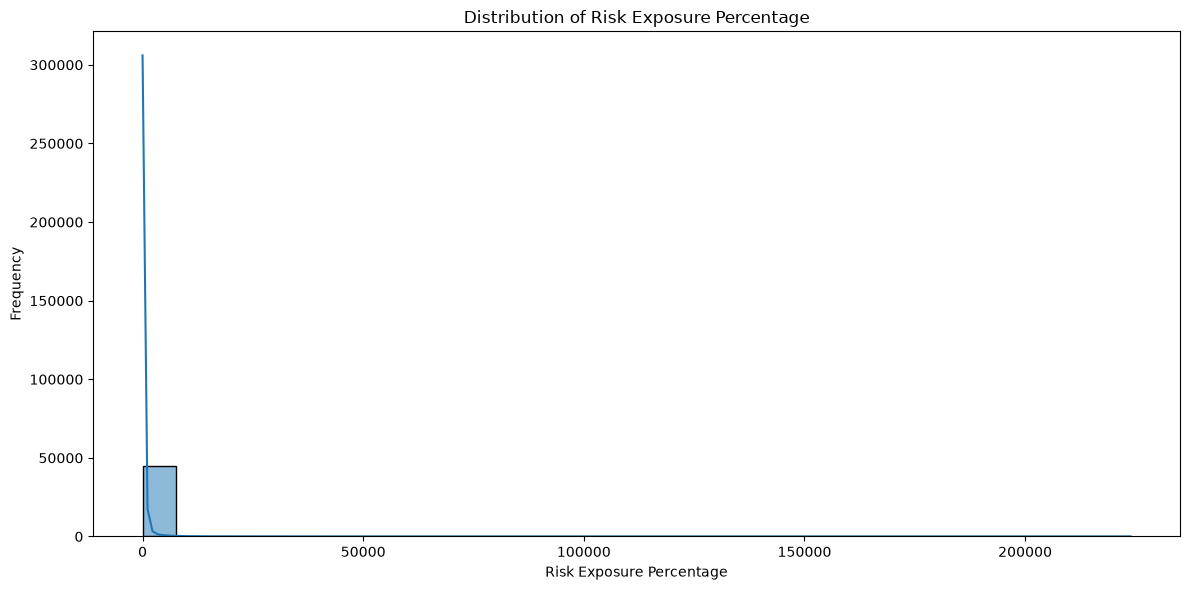

In [46]:
# 4. Distribution of Risk Exposure Percentage

plt.figure(figsize=(12, 6))

sns.histplot(df["risk_exposure_percentage"], bins=30, kde=True)

plt.title("Distribution of Risk Exposure Percentage")
plt.xlabel("Risk Exposure Percentage")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("risk_exposure_distribution.png", dpi=500)
plt.show()

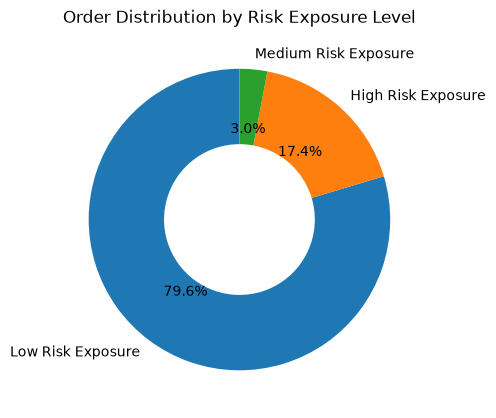

In [47]:
# 5. Order Distribution by Risk Exposure Level

risk_distribution = df["risk_exposure_bucket"].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    risk_distribution.values,
    labels=risk_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.5)
)

plt.title("Order Distribution by Risk Exposure Level")

plt.tight_layout()
plt.savefig("risk_exposure_donut.png", dpi=500)
plt.show()

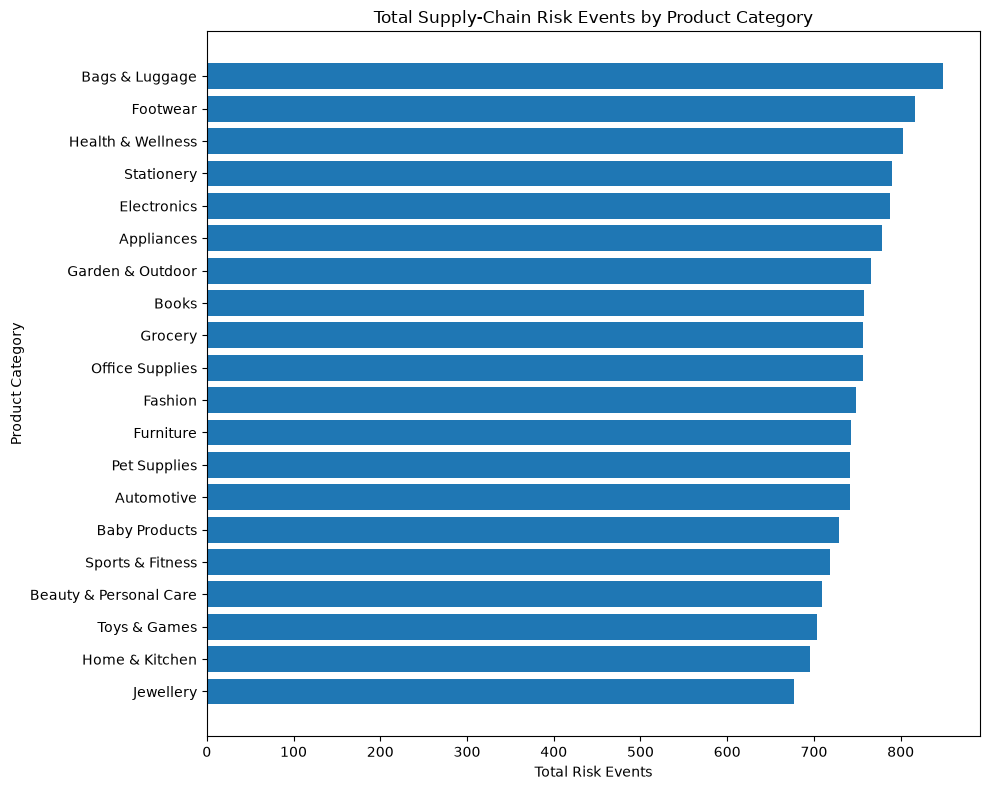

In [48]:
# 6. Total Risk Events by Product Category

category_risk_events = (df.groupby("category_name")["risk_event_count"].sum().sort_values(ascending=True))

plt.figure(figsize=(10, 8))

plt.barh(category_risk_events.index, category_risk_events.values)

plt.title("Total Supply-Chain Risk Events by Product Category")
plt.xlabel("Total Risk Events")
plt.ylabel("Product Category")

plt.tight_layout()
plt.savefig("risk_events_by_category.png", dpi=500)
plt.show()